# Benchmarking V2
## 0. Imports and Set-Up:

### 0.1 Imports, Seed-Setting, Plotting-Helper-Function:

In [1]:
import multiprocessing

from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from typing import Dict, List, Tuple, Type

from sklearn.base import ClusterMixin
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, pairwise_distances, silhouette_score
from sklearn.utils import check_random_state

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

import pyreadr

In [2]:
import sys
print("Interpreter:", sys.executable)

import carve
print("carve from:", carve.__file__)

import inspect
print("Public names:", [n for n in dir(carve) if not n.startswith("_")])
print("Classes:", [n for n, o in inspect.getmembers(carve, inspect.isclass) if o.__module__.startswith("carve")])
print("Functions:", [n for n, o in inspect.getmembers(carve, inspect.isfunction) if o.__module__.startswith("carve")])

Interpreter: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/.venv/bin/python
carve from: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/__init__.py
Public names: ['CARVE', 'SpectralClusteringCARVE', 'api', 'cluster', 'config', 'grids']
Classes: ['CARVE', 'SpectralClusteringCARVE']
Functions: []


In [3]:
import carve.sim
print("carve.sim from:", carve.sim.__file__)

import inspect
print("Public names:", [n for n in dir(carve.sim) if not n.startswith("_")])
print("Classes:", [n for n, o in inspect.getmembers(carve.sim, inspect.isclass) if o.__module__.startswith("carve.sim")])
print("Functions:", [n for n, o in inspect.getmembers(carve.sim, inspect.isfunction) if o.__module__.startswith("carve.sim")])

carve.sim from: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/sim/__init__.py
Public names: ['ScDesign3Simulator', 'api', 'simulate_clusters']
Classes: ['ScDesign3Simulator']
Functions: ['simulate_clusters']


In [4]:
from carve import CARVE
from carve.config import ValidatorConfig

from carve.sim import simulate_clusters

In [5]:
def gamma_quantiles(X, qs=(0.05, 0.10, 0.25, 0.50)):
    D2 = pairwise_distances(X, metric='sqeuclidean')
    d2 = D2[np.triu_indices_from(D2, k=1)]
    return [1.0 / (2.0 * np.quantile(d2, q)) for q in qs]

---

## 1. Benchmarking

In [6]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


Gap-Statistics:

In [7]:
def compute_dispersion(X: np.ndarray, labels: np.ndarray, metric: str = 'euclidean') -> float:
    """
    Compute within-cluster dispersion W_k.

    :param X: data matrix on which clusters were computed
    :param labels: cluster labels for X
    :param metric: the distance metric to be used when calculating pairwise distances. Valid values are: 
        From scikit-learn: ['cityblock', 'cosine', 'euclidean', 'l1', 'l2', 'manhattan', 'nan_euclidean']
        From scipy.spatial.distance: ['braycurtis', 'canberra', 'chebyshev', 'correlation', 'dice', 'hamming', 'jaccard', 'kulsinski', 
            'mahalanobis', 'minkowski', 'rogerstanimoto', 'russellrao', 'seuclidean', 'sokalmichener', 'sokalsneath', 'sqeuclidean', 'yule']

    :return: within-cluster dispersion W_k
    """
    unique_labels = np.unique(labels)
    W_k = 0.0
    
    for label in unique_labels:
        cluster_points = X[labels == label]
        
        if len(cluster_points) <= 1:
            continue
        
        distances = pairwise_distances(cluster_points, metric=metric)
        W_k += np.sum(distances) / (2 * cluster_points.shape[0])
    
    return W_k

def gen_null(X: np.ndarray, _: int, random_state: int) -> np.ndarray:
    """
    Generate a single null-distribution dataset.

    :param X: reference dataset
    :param _: dummy index for Parallel
    :param random_state: random state for the random number generator
    
    :return: null-distribution dataset of same shape as X
    """
    rng = check_random_state(random_state)
    n_samples, p = X.shape
    
    X_ref = np.empty_like(X)
    for j in range(p):
        X_ref[:, j] = rng.uniform(np.min(X[:, j]), np.max(X[:, j]), size=n_samples)
        
    return X_ref

def gap_statistic(
    X: np.ndarray, 
    labels: np.ndarray, 
    metric: str = 'euclidean', 
    n_refs: int = 10, 
    algorithm: Type[ClusterMixin] = KMeans, 
    random_state: str = None
) -> float:
    """
    Computes the gap statistic for a given clustering assignment, as introduced by Tibshirani et al. (2001).

    :param X: data matrix on which clusters were computed
    :param labels: cluster labels for X
    :param metric: the distance metric to be used when calculating pairwise distances. Valid values are: 
        From scikit-learn: ['cityblock', 'cosine', 'euclidean', 'l1', 'l2', 'manhattan', 'nan_euclidean']
        From scipy.spatial.distance: ['braycurtis', 'canberra', 'chebyshev', 'correlation', 'dice', 'hamming', 'jaccard', 'kulsinski', 
            'mahalanobis', 'minkowski', 'rogerstanimoto', 'russellrao', 'seuclidean', 'sokalmichener', 'sokalsneath', 'sqeuclidean', 'yule']
    :param n_refs: number of reference datasets to generate under the null hypothesis (no clustering structure)
    :param algorithm: sklearn clustering algorithm to cluster the null-distribution dataset
    :param random_state: a random state

    :return: The gap statistic; difference between the expected log within-cluster dispersion 
        under the null model and the observed log dispersion from the provided clustering
    """
    num_cores = max(1, multiprocessing.cpu_count() - 1)
    
    rng = check_random_state(random_state)
    W_k = compute_dispersion(X, labels, metric)
    
    # generate and cluster null-models
    def _compute_ref_disp(i: int) -> float:
        X_ref = gen_null(X, i, rng.randint(0, 1e6))

        k = len(np.unique(labels))
        model = algorithm(n_clusters=k)
        ref_labels = model.fit_predict(X_ref)

        return np.log(compute_dispersion(X_ref, ref_labels, metric))

    ref_log_disps = Parallel(n_jobs=num_cores)(
        delayed(_compute_ref_disp)(i) for i in range(n_refs)
    )
        
    log_W_k = np.log(W_k)
    log_w_k_ref = np.mean(ref_log_disps)
    
    gap = log_w_k_ref - log_W_k
    return gap

Output plotting:

---

### 2.1 Data Import:

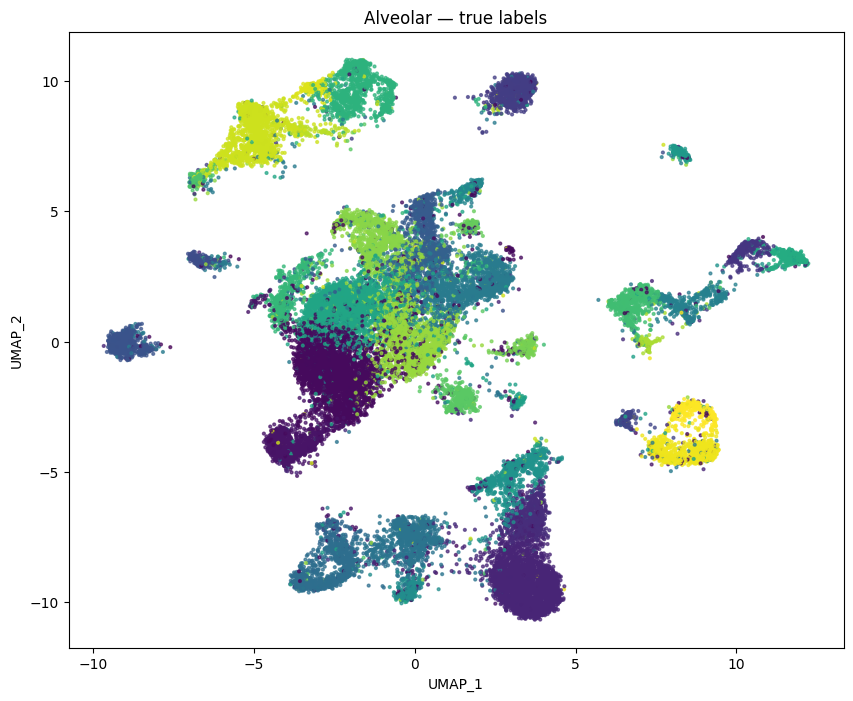

n_classes = 39


In [8]:
# 1) load X and y exported from R
X_umap = next(iter(pyreadr.read_r("../data/scDeed/alveolar_umap.rds").values()))   # DataFrame with rownames in index
y_df = next(iter(pyreadr.read_r("../data/scDeed/alveolar_labels_celltype.rds").values()))

# 2) inner-join by cell_id (index)
df = X_umap.join(y_df, how="inner")

# 3) build X (2D UMAP) and y (true labels)
X = df.filter(regex=r"^UMAP_", axis=1).to_numpy(dtype=float)   # columns: 'UMAP_1','UMAP_2'
y = df["cell_type"].astype("category").to_numpy()

# 4) quick viz colored by labels
plt.figure(figsize=(10, 8))
plt.scatter(X[:,0], X[:,1], c=pd.Categorical(df["cell_type"]).codes, s=4, alpha=0.7)
plt.xlabel("UMAP_1"); plt.ylabel("UMAP_2"); plt.title("Alveolar — true labels")
plt.show()

# 5) number of classes
n_classes = pd.Series(y).nunique()
print("n_classes =", n_classes)

In [ ]:
cfg = ValidatorConfig(
    X=X,
    ref_labels=y,
    model_grids=[(SpectralClustering, {"n_clusters": [35, 36, 37, 38, 39, 40, 41, 42, 43, 44]})]
)

val = CARVE(cfg)
val.validate(prog_bar=True, random_state=123)

Grid configs:   0%|          | 0/11 [00:00<?, ?it/s]